# The Profanity Project

## Introduction & Background

This research aims to study the contextual application of profanity across different music genres. By comparing different popular genres including rap and pop, we aim to provide a nuanced perspective on language in popular music, potentially challenging (or reaffirming) stereotypes regarding the use of explicit language within rap. Common preconceptions suggest that rap music is characterised as aggressive, offensive, misogynistic or even violent in its use of profanity (Howard et al., 2021). A study found that rap accounted for 76% of profanity within top 10 songs in the Billboard Hot 100 from 2009-2018 (Moloney and Sylva, 2020). Another study found that rap ranked number one for the most profanity used, with a swear word in every 47 words, and pop ranked number four, with a swear word every 904 words (Medium, 2015). 

However, profanity can serve various purposes, from expressing intense emotions (both positive and negative) to emphasising statements or simply being used as a device to create linguistic rhythm. For instance, while the term 'bitch' is frequently employed as a word used to dehumanise and to insult women, it can also be utilized as a symbol of empowerment or an expression of camaraderie. This research aims to provide a nuanced perspective on the complex role of profanity in popular music, contributing to a more comprehensive understanding of linguistic choices in contemporary musical expression.

Pop music is often produced for mass consumption, so characteristics of pop music tend to include catchy, simple melodies, repetitive beats and straightforward lyrics (Musical Dictionary, 2024). As a result, it’s often the most accessible music and most recognisable genre of music, but due to its broad target audience, pop music typically avoids the use of profanity or incorporates it sparingly. Conversely, rap music, while also a form of popular music, emerged in the 1970s through the creativity of urban Black performers. It is commonly identified by its repetitive beat patterns and rapid, slang-heavy, and often boastful rhyming vocal delivery (Dictionary.com, 2025).

Over the past decade, rap music has achieved significant prominence in mainstream media, propelled by artists such as Kendrick Lamar, Travis Scott, and Drake, and now accounts for a substantial share of contemporary music airplay (Bruner, 2018). The goal of this project is to conduct research that explores usage of profanity in rap and pop music lyrics, addressing the question: 
- *How does the sentiment and usage of profanity differ between rap and pop music lyrics, and does this support or challenge stereotypes about profanity in rap music?*

To gain insight into the music commonly consumed by the general public within the rap and pop genres, this study utilizes Apple Music's playlists, *Top 100 2024: Shazam’s Radio Chart*. This resource includes curated playlists for several genres, including hip-hop and pop, comprising songs that are currently popular on radio stations worldwide. As such, it serves as a representative sample of the music that is most likely being listened to by the general public. 

Although an explicit rap playlist was not available, we determined that the hip-hop playlist would be a suitable alternative, given the close relationship between the two terms and their frequent interchangeable use. While all rap falls under the umbrella of hip-hop, not all hip-hop is rap, as hip-hop also encompasses instrumental tracks and other vocal styles. In mainstream media, however, the term "hip-hop" is often used synonymously with rap. It is important to emphasize that hip-hop represents a broader cultural movement, whereas rap is the musical art form that serves as a central component of this culture (Medium, 2022).


## Tutorial

### Collecting the data

#### Web scrape lists of song title + artist for each genre

Web scrape from *Top 100 2024: Shazam Radio Charts*:\
Hip-Hop: https://music.apple.com/be/playlist/top-100-2024-shazam-radio-chart-hip-hop/pl.745180bfbd374d56aa07d84c9420e5dc

Pop: https://music.apple.com/nl/playlist/top-100-2024-shazam-radio-chart-pop/pl.bdb7c5da0c8c44479af4299a62c67b78?l=en-GB

**! Used selenium i.o. Beatifulsoup because:** 

The data we want to scrape is dynamically loaded, meaning that it is not present in the initial HTML response that you receive when you make a request to a webpage (with BeautifulSoup). Instead, the content is generated and inserted into the page after the initial load, typically through JavaScript.  

For example, a webpage might initially load a blank list and then use JavaScript to fetch and display song titles and artists from a server after the page has loaded. If you view the page source in this case, you may not see the song titles and artists because they are added to the DOM after the page has loaded.  

Selenium is a web automation tool that can control a web browser programmatically. It can wait for JavaScript to execute and for elements to be rendered on the page, allowing you to scrape content that is dynamically loaded.

In [7]:
!pip install -q selenium
!pip install -q webdriver-manager
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

def scrape_music_data(url):
    # Set up Selenium WebDriver
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service)

    # Initialise empty song_titles and artists lists
    song_titles = []
    artists = []

    # Open the webpage
    driver.get(url)

    try:
        # Wait for the song titles to be present
        WebDriverWait(driver, 10).until(
            EC.presence_of_all_elements_located((By.CLASS_NAME, 'songs-list-row__song-name'))
        )

        # Find all song title elements
        title_tags = driver.find_elements(By.CLASS_NAME, 'songs-list-row__song-name')

        # Extract song titles
        song_titles = [title.text for title in title_tags]

        # Find all song artist containers
        artist_containers = driver.find_elements(By.XPATH, "//div[contains(@class, 'songs-list__col songs-list__col--secondary svelte-113if15')]")

        # Extract the first artist from each song
        for container in artist_containers:
            # Find all artist <a> tags in the current container
            artist_tags = container.find_elements(By.XPATH, ".//a[@data-testid='click-action']")
            
            # Only append the first artist (some songs have more than one artist)
            artists.append(artist_tags[0].text)

    except Exception as e:
        print("An error occurred:", e)
        return []  # Return an empty list on error

    finally:
        # Close the driver
        driver.quit()

    # Create a list of tuples (song, artist)
    song_artist_tuples = list(zip(song_titles, artists))

    return song_artist_tuples

In [8]:
url = 'https://music.apple.com/be/playlist/top-100-2024-shazam-radio-chart-hip-hop/pl.745180bfbd374d56aa07d84c9420e5dc'
songs_hh = scrape_music_data(url)

An error occurred: Message: no such window: target window already closed
from unknown error: web view not found
  (Session info: chrome=134.0.6998.166)
Stacktrace:
	GetHandleVerifier [0x0030C7F3+24435]
	(No symbol) [0x00292074]
	(No symbol) [0x001606E3]
	(No symbol) [0x0013F83E]
	(No symbol) [0x001D455E]
	(No symbol) [0x001EEB19]
	(No symbol) [0x001CD5B6]
	(No symbol) [0x0019C54F]
	(No symbol) [0x0019D894]
	GetHandleVerifier [0x006170A3+3213347]
	GetHandleVerifier [0x0062B0C9+3295305]
	GetHandleVerifier [0x0062558C+3271948]
	GetHandleVerifier [0x003A7360+658144]
	(No symbol) [0x0029B27D]
	(No symbol) [0x00298208]
	(No symbol) [0x002983A9]
	(No symbol) [0x0028AAC0]
	BaseThreadInitThunk [0x75C9FCC9+25]
	RtlGetAppContainerNamedObjectPath [0x778882AE+286]
	RtlGetAppContainerNamedObjectPath [0x7788827E+238]
	(No symbol) [0x00000000]



In [9]:
url = 'https://music.apple.com/nl/playlist/top-100-2024-shazam-radio-chart-pop/pl.bdb7c5da0c8c44479af4299a62c67b78?l=en-GB'
songs_pop = scrape_music_data(url)

An error occurred: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))


#### Format Song titles + Artists for automation process


In [10]:
import re

def format_song_data(song_data):
    formatted_data = []
    for title, artist in song_data:
        # Replace specific artist names
        artist_replacements = {
            'Macklemore & Ryan Lewis': 'macklemore',
            'Latto': 'missmulatto',
            'GIMS': 'matregims',
            'The Notorious B.I.G.': 'notoriousbig',
            'The Kid LAROI': 'kidlaroi',
            'P!nk': 'pink',
            'The Human League': 'humanleague'
        }
        
        # Replace the artist name if it matches any key in the replacements dictionary
        artist = artist_replacements.get(artist, artist)

        # Remove text in brackets and square brackets, and punctuation, then format to lowercase and remove spaces
        formatted_title = re.sub(r'\(.*?\)|\[.*?\]', '', title)
        formatted_title = re.sub(r'[^\w\s]', '', formatted_title)  
        formatted_title = formatted_title.lower().replace(" ", "")
        
        # Replace 'ºC' in the title
        formatted_title = formatted_title.replace('ºc', 'oc')  # Ensure 'ºC' is replaced with 'oc'

        formatted_artist = re.sub(r'\(.*?\)|\[.*?\]', '', artist)  # Remove text in brackets and square brackets
        formatted_artist = re.sub(r'[^\w\s]', '', formatted_artist)  # Remove punctuation
        formatted_artist = formatted_artist.lower().replace(" ", "")
        
        # Append the formatted tuple to the list
        formatted_data.append((formatted_title, formatted_artist))
    return formatted_data

#### Web scrape Lyrics
Used BeautifulSoup

In [11]:
# Create functions

import requests
from bs4 import BeautifulSoup

def scrape_lyrics(formatted_title, formatted_artist):
    url = f'https://www.azlyrics.com/lyrics/{formatted_artist}/{formatted_title}.html'

    try:
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad responses
        document = BeautifulSoup(response.text, 'html.parser')

        lyrics_tag = document.find_all("div", attrs={"class": None, "id": None})
        lyrics = []
        for content in lyrics_tag:
            line = content.get_text(separator=" ")
            lyrics.append(line.strip())

        # Join lines with newline characters
        lyrics_text = "\n".join(lyrics)
        
        return lyrics_text

    except requests.exceptions.RequestException as e:
        print(f"Error fetching lyrics for {formatted_title} by {formatted_artist}: {e}")
        return None

import os

def save_lyrics_to_file(formatted_title, formatted_artist, lyrics, genre):
    # Create a directory for the genre if it doesn't exist
    os.makedirs(f'lyrics/{genre}', exist_ok=True)
    
    # Create a safe filename
    filename = f"lyrics/{genre}/{formatted_artist}_{formatted_title}.txt"
    
    # Write lyrics to the file
    with open(filename, 'w', encoding='utf-8') as file:
        file.write(lyrics)
    print(f"Lyrics saved to {filename}")


#### Hip-Hop

In [12]:
import time

# Loop through each hip-hop song and scrape + save their lyrics

# Format the title + artist
formatted_songs_hh = format_song_data(songs_hh)

# Extract lyrics, create directory for hip-hop songs and save each lyric in a .txt file
for formatted_title, formatted_artist in formatted_songs_hh:
    lyrics = scrape_lyrics(formatted_title, formatted_artist)
    if lyrics:
        save_lyrics_to_file(formatted_title, formatted_artist, lyrics, 'hiphop')
        print(f"Lyrics for {formatted_title} by {formatted_artist} have been saved in the hiphop folder.\n")
    else:
        print(f"Failed to scrape lyrics for: {formatted_title} by {formatted_artist}")

    time.sleep(10)  # Sleep to avoid triggering anti-bot measures.


#### Pop

In [13]:
# Loop through each pop song and scrape + save their lyrics

formatted_songs_pop = format_song_data(songs_pop)

for formatted_title, formatted_artist in formatted_songs_pop:
    lyrics = scrape_lyrics(formatted_title, formatted_artist)
    if lyrics:
        save_lyrics_to_file(formatted_title, formatted_artist, lyrics, 'pop')
        print(f"Lyrics for {formatted_title} by {formatted_artist} have been saved in the pop folder.\n")
    else:
        print(f"Failed to scrape lyrics for: {formatted_title} by {formatted_artist}")

    time.sleep(10)

Despite best efforts to account for certain non-regular formatted song titles and artist in the `format_song_data` function, some lyrics still failed to scrape due to their non-regular AZlyrics URL or not using the same artist from the top 100 shazam chart list in the URL if a song has multiple artists, and also the dynamic structure of the top 100 list.

**The (6) Hip-Hop songs that failed to scrape:** \
('What It Is (Block Boy) [feat. Kodak Black]', 'Doechii')\
https://www.azlyrics.com/lyrics/iamdoechii/whatitisblockboy.html

('Quevedo: Bzrp Music Sessions, Vol. 52', 'Bizarrap')\
https://www.azlyrics.com/lyrics/bizarrap/quevedobzrpmusicsessions52.html

('I Like You (A Happier Song) [feat. Doja Cat]', 'Post Malone')\
https://www.azlyrics.com/lyrics/postmalone/ilikeyouahappiersong.html

('Petit génie (feat. Abou Debeing & Lossa)', 'Jungeli')\
https://www.azlyrics.com/lyrics/imenes/petitgenie.html

('I Know You Want Me (Calle Ocho)', 'Pitbull')\
https://www.azlyrics.com/lyrics/pitbull/iknowyouwantmecalleocho.html

("Buy U a Drank (Shawty Snappin') [feat. Yung Joc]", 'T-Pain')\
https://www.azlyrics.com/lyrics/tpain/buyuadrankshawtysnappin.html

**The (10) Pop songs that failed to scrape:** 

("we can't be friends (wait for your love)", 'Ariana Grande')\
https://www.azlyrics.com/lyrics/arianagrande/wecantbefriendswaitforyourlove.html

('Cold Heart (PNAU Remix)', 'Elton John')\
https://www.azlyrics.com/lyrics/eltonjohn/coldheartpnauremix.html

("Is It Over Now? (Taylor's Version) [From The Vault]", 'Taylor Swift')\
https://www.azlyrics.com/lyrics/taylorswift/isitovernowtaylorsversionfromthevault.html

('Dreaming', 'P!nk')\
https://www.azlyrics.com/lyrics/marshmello/dreaming.html

('Sweet Dreams (Are Made of This)', 'Eurythmics')\
https://www.azlyrics.com/lyrics/eurythmics/sweetdreamsaremadeofthis.html

('Si No Estás', 'iñigo quintero')\
https://www.azlyrics.com/lyrics/inigoquintero/sinoestas.html

('Señorita', 'Camila Cabello')\
https://www.azlyrics.com/lyrics/shawnmendes/senorita.html

('I Gotta Feeling', 'Black Eyed Peas')\
https://www.azlyrics.com/lyrics/blackeyedpeas/igottafeelin.html

('Doctor (Work It Out)', 'Pharrell Williams')\
https://www.azlyrics.com/lyrics/pharrellwilliams/doctorworkitout.html

("(I've Had) The Time of My Life", 'Jennifer Warnes')\
https://www.azlyrics.com/lyrics/jenniferwarnes/ivehadthetimeofmylife.html

### Managing the data

The dataset was scanned for the frequency of occurrence of each word from this [list](https://gist.github.com/ryanlewis/a37739d710ccdb4b406d) of swear words. - *Explain the source of list*

In [14]:
import os
import pandas as pd
import re
from collections import Counter
!pip install -q langdetect
from langdetect import detect, DetectorFactory
import csv

# Create functions

# Set seed for reproducibility
DetectorFactory.seed = 0

def preprocess_lyrics(lyrics):
    """Convert lyrics to lowercase, remove punctuation, and remove empty lines."""
    lyrics = lyrics.lower()
    lyrics = re.sub(r'[^\w\s]', '', lyrics)
    lines = lyrics.splitlines()
    non_empty_lines = [line for line in lines if line.strip()]
    return non_empty_lines 

def load_profanity_list(file_path):
    """Load the profanity list from a file."""
    with open(file_path, 'r') as f:
        profanity_list = [line.strip().lower() for line in f.readlines()]
    return profanity_list

def extract_profanity_lines(processed_lines, profanity_list):
    """Extract lines containing profanities and return them along with context."""
    profanity_lines = []
    
    for index, line in enumerate(processed_lines):
        for profanity in profanity_list:
            # Use regex to check for whole word matches
            if re.search(r'\b' + re.escape(profanity) + r'\b', line, flags=re.IGNORECASE):
                # Initialize before and after lines
                before = processed_lines[index - 1] if index > 0 else ""  # Line before, or empty if it's the first line
                after = processed_lines[index + 1] if index < len(processed_lines) - 1 else ""  # Line after, or empty if it's the last line
                profanity_lines.append((before, line, after, profanity))  # Include the specific profanity
                # No break here, continue to find other profanities in the same line

    return profanity_lines

def highlight_profanity(profanity_line, profanity_list):
    """Highlight profanity words in the given line by converting them to uppercase."""
    for profanity in profanity_list:
        # Use regex to replace the profanity with its uppercase version
        profanity_line = re.sub(
            r'\b' + re.escape(profanity) + r'\b',  # Ensure whole word match
            lambda match: match.group(0).upper(),  # Convert matched profanity to uppercase
            profanity_line,
            flags=re.IGNORECASE
        )
    return profanity_line

In [15]:
# Combine functions into one

def analyse_lyrics(base_directory='lyrics', profanity_file='profanity_list'):
    # Load the profanity list
    profanity_list = load_profanity_list(profanity_file)
    
    # DataFrame to store profanity lines
    profanity_data = []
    
    # Counters for total word count and profanity count
    genre_word_count = {'hiphop': 0, 'pop': 0}
    genre_profanity_count = {'hiphop': 0, 'pop': 0}
    profanity_frequency = {'hiphop': Counter(), 'pop': Counter()}

    # Walk through the base directory
    for genre in os.listdir(base_directory):
        genre_path = os.path.join(base_directory, genre)
        
        if os.path.isdir(genre_path):
            for filename in os.listdir(genre_path):
                if filename.endswith('.txt'):
                    # Read the lyrics from the file
                    with open(os.path.join(genre_path, filename), 'r', encoding='utf-8') as file:
                        lyrics = file.read()
                    
                    # Check if the lyrics are in English
                    try:
                        if detect(lyrics) != 'en':
                            continue  # Skip non-English lyrics
                    except Exception as e:
                        print(f"Error detecting language for {filename}: {e}")
                        continue

                    # Extract song title and artist from the filename
                    name_without_extension = filename[:-4]
                    parts = name_without_extension.split('_', 1)
                    if len(parts) == 2:
                        formatted_artist = parts[0]
                        formatted_title = parts[1]
                        
                        # Preprocess the lyrics
                        processed_lines = preprocess_lyrics(lyrics)
                        
                        # Calculate total word count
                        word_count = sum(len(line.split()) for line in processed_lines)
                        genre_word_count[genre] += word_count
                        
                        # Extract profanity lines
                        profanity_lines = extract_profanity_lines(processed_lines, profanity_list)
                        genre_profanity_count[genre] += len(profanity_lines)

                        # Count frequency of each profanity
                        for before, line, after, profanity in profanity_lines:
                            highlighted_profanity_line = highlight_profanity(line, profanity_list)

                            # Combine lines into one string with line breaks
                            combined_line = f"{before}\n{highlighted_profanity_line}\n{after}" 
                            profanity_data.append((formatted_title, formatted_artist, genre, combined_line))

                            # Count frequency of each profanity
                            if profanity in line:
                                profanity_frequency[genre][profanity] += 1

    # Create a DataFrame from the extracted profanity lines
    df_profanity = pd.DataFrame(profanity_data, columns=['Song Title', 'Artist', 'Genre', 'Profanity Lines'])

    # Create new empty column for sentiment annotation
    df_profanity['Sentiment Annotation'] = None  

    # Print results
    print("Total Word Count by Genre:", genre_word_count)
    print("Total Profanity Count by Genre:", genre_profanity_count)
    print("Profanity Frequency by Genre:", {genre: dict(freq) for genre, freq in profanity_frequency.items()})
    
    return df_profanity, genre_word_count, genre_profanity_count, profanity_frequency 

In [16]:
# Call the function
df_profanity, genre_word_count, genre_profanity_count, profanity_frequency = analyse_lyrics()

Total Word Count by Genre: {'hiphop': 43815, 'pop': 31335}
Total Profanity Count by Genre: {'hiphop': 633, 'pop': 92}
Profanity Frequency by Genre: {'hiphop': {'bitch': 85, 'nigga': 73, 'niggas': 50, 'ass': 49, 'pussy': 29, 'shit': 71, 'fuckin': 25, 'sex': 15, 'fuck': 59, 'motherfucker': 16, 'porno': 1, 'damn': 34, 'hell': 10, 'bitches': 38, 'titties': 2, 'dick': 15, 'penis': 1, 'butt': 2, 'motherfuckin': 5, 'fucking': 12, 'cock': 2, 'prick': 2, 'balls': 2, 'goddamn': 1, 'pissed': 2, 'bum': 5, 'clitoris': 1, 'asses': 2, 'viagra': 1, 'cum': 1, 'shits': 2, 'tits': 2, 'tit': 1, 'fag': 1, 'pornography': 1, 'fucked': 10, 'motherfuck': 1, 'pussies': 1, 'piss': 1, 'dink': 1, 'crap': 1}, 'pop': {'shit': 26, 'fuckin': 4, 'ass': 1, 'lust': 1, 'faggot': 3, 'hell': 8, 'damn': 18, 'sex': 1, 'fucked': 6, 'fuck': 3, 'bitch': 8, 'goddamn': 8, 'fucks': 1, 'motherfucker': 2, 'snatch': 2}}


In [17]:
# Save the DataFrame to a CSV file
df_profanity.to_csv('full_profanity_lyrics_corpus.csv', index=False, quoting=csv.QUOTE_ALL) # Use index=False to avoid writing row indices

In [18]:
# Create smaller Dataframe for pilot annotation with 20 rows from each genre

# Initialize an empty list to hold the smaller DataFrame rows
smaller_df_rows = []

# Get the unique genres in the DataFrame
genres = df_profanity['Genre'].unique()

# Loop through each genre and sample the specified number of rows
for genre in genres:
    genre_rows = df_profanity[df_profanity['Genre'] == genre]
    sampled_rows = genre_rows.sample(n=min(20, len(genre_rows)), random_state=1)  # Sample with a fixed random state for reproducibility
    smaller_df_rows.append(sampled_rows)

# Concatenate the sampled rows into a new DataFrame
df_profanity_pilot = pd.concat(smaller_df_rows, ignore_index=True)

# Save the DataFrame to a CSV file
df_profanity_pilot.to_csv('pilot_profanity_lyrics_corpus.csv', index=False, quoting=csv.QUOTE_ALL) # Use index=False to avoid writing row indices

### Data Exploration 

As part of the _analyse_lyrics_ function, three dictionaries were created. These are as follows: 
1. _genre_word_count_ gives us the total number of words in the lyrics from hip-hop and pop.
2. _genre_profanity_count_ gives us the total number of times profanity was present in each genre.
3. _profanity_frequency_ gives us the frequency of occurence of each profanity per genre

Visualising these dictionaries in different ways allows us to explore the data collected and processed up until this point and helps answer part of the research question. Sepecifically, how does the usage of profanity differ between hip-hop and pop lyrics?  
<br>

Installing Libraries and Importing Modules

In [19]:
%%capture
!pip install matplotlib seaborn

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#### Number of Words and Swear Words in Hip Hop and Pop

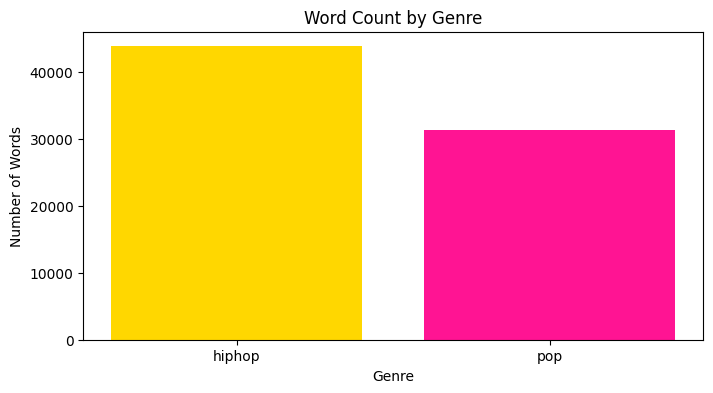

In [77]:
#Visualising genre word count
genres = genre_word_count.keys()
word_count = genre_word_count.values()

#create a boxplot
plt.figure(figsize=(8, 4))
plt.bar(genres, word_count, color=['gold', 'deeppink'])

plt.title('Word Count by Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Words')

plt.show()

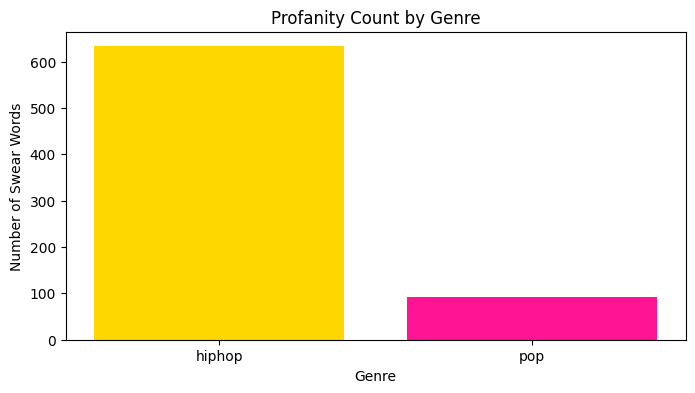

In [78]:
#Visualising profanity count per genre
genres = genre_profanity_count.keys()
profanity_count = genre_profanity_count.values()

#create a boxplot
plt.figure(figsize=(8, 4))
plt.bar(genres, profanity_count, color=['gold', 'deeppink'])

plt.title('Profanity Count by Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Swear Words')
plt.show()

<br>
From the visualisations above, we can see that not only does hip hop contain more words in general, it also clearly makes use of significantly more profanity within its lyrics. As noted in the introduction, hip hop is not the same as rap but the genre includes rap and rap verses. Rap artists inherently fits more words in less time than pop artists tend to, which explains the almost thousand words difference between total words per genre in the corpus. The latter bar plot also supports past studies regarding the sheer amount of curse words within rap/hip hop as compared to pop, which is meant to be more radio friendly and for a more varied demographic. <br> 
With that in mind, we have the visualisations below: <ol>
<li>A pie chart visualising the proportion of profanity per genre. </li> 
<li>A stacked bar chart of the 20 most used swear words</li>
</ol>


#### Profanity Frequency Visualisations


In [87]:
#functions to create visualisations
def create_pie_chart(profanity_frequency):
    total_counts = {
        'Hip Hop': sum(profanity_frequency['hiphop'].values()),
        'Pop': sum(profanity_frequency['pop'].values())
    }

    colors = ['gold', 'deeppink']

    plt.figure(figsize=(6, 6))
    plt.pie(total_counts.values(), labels=total_counts.keys(), autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title('Proportion of Profanity by Genre')
    plt.axis('equal')  
    plt.show()


def create_stacked_bar_chart(profanity_frequency):
    all_words = set(profanity_frequency['hiphop'].keys()).union(set(profanity_frequency['pop'].keys()))
    data = {
        'Curse Word': list(all_words),
        'Hip Hop': [profanity_frequency['hiphop'][word] for word in all_words],
        'Pop': [profanity_frequency['pop'][word] for word in all_words]
    }
    df_stacked = pd.DataFrame(data)

    # Set the index to the curse words
    df_stacked.set_index('Curse Word', inplace=True)

    # Calculate total frequency and sort the DataFrame
    df_stacked['Total Frequency'] = df_stacked['Hip Hop'] + df_stacked['Pop']
    df_stacked = df_stacked.sort_values(by='Total Frequency', ascending=False)  
    df_stacked = df_stacked.head(20) # Limit to the top 20 most common swear words
    df_stacked = df_stacked.iloc[::-1]  # Reverse the order of the DataFrame for plotting 

    ax = df_stacked[['Hip Hop', 'Pop']].plot(kind='barh', stacked=True, figsize=(10, 6), color=['gold', 'deeppink'], width=0.6) 
    plt.title('Top 20 Profanity Frequency by Genre', fontsize=16)
    plt.xlabel('Frequency', fontsize=14)
    plt.ylabel('Curse Word', fontsize=14)

    plt.legend(title='Genre')
    plt.tight_layout()  
    plt.show()

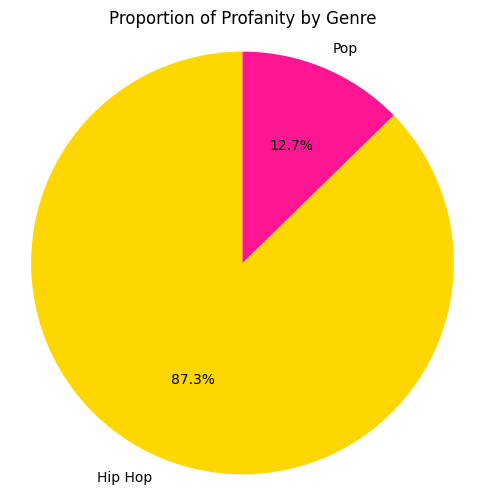

In [88]:
create_pie_chart(profanity_frequency)

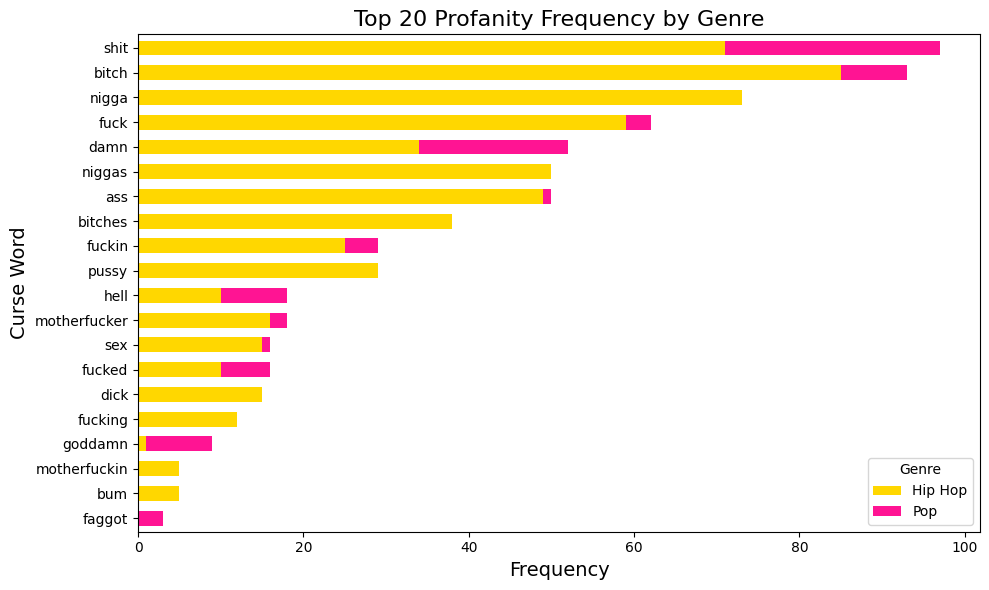

In [89]:
create_stacked_bar_chart(profanity_frequency)

The pie chart above shows makes more explicit (than the earlier bar plot) how much of the swear words are present in each of the genres within our corpus - 87.3% in hip hop and 12.7% in pop lyrics. 
<br>
<br>
After that, we explored which swear words were used most often and in which genre. This was done by visualising the data as a stacked bar plot and limiting it to the 20 most used words. As expected, they were mostly used within hip hop though there were a few interesting things to note. The more 'mild' or less explicit curse words like 'shit', 'damn', and 'hell' were among those found most often in pop with 'goddamn' being the word found far more times in pop than hip hop. The surprise was 'fa***t' being only pink in the above bar plot. There may be multiple explanations for this, but one possibility might be the fact that with the rise in popularity of rap, more and more rappers are being featured in pop songs. It could also be the result of songs being classified as pop due to their popularity though they would fit better culturally and per convention in hip hop/rap. It was also a surprise to note how many of the more explicit swear words were used in pop lyrics, despite the fact that the genre and its artists tend to, as noted in the introduction, "avoids the use of profanity or incorporates it sparingly". 

### Data Analysis

To further analyse the use of profanity in the corpus, 724 lines of lyrics containing profanity were annotated according to the annotation guidelines by two of the three members of this group. This was after they completed a pilot annotation on the smaller corpus of 20 lines created by the function earlier in this notebook. To confirm the accuracy of the annotations per the guidelines, their Cohen's Kappa must be determined. <br>

*Calculating Inter-Annotator Agreement* <br>
Before conducting a sentiment analysis on the use of profanity in our corpus, we must first be in agreement regarding what counts as positive, negative, and neutral use of profanity. The following is the calaculation of the Cohen's Kappa - which measures how much of the possible agreement was obtained beyond the possibility of accidental agreement. 

In [31]:
import numpy as np
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix

In [32]:
annotator_n = [3, 3, 3, 3, 3, 2, 2, 1, 0, 3, 3, 2, 2, 2, 2, 3, 2, 1, 2, 2, 2, 2, 3, 3, 3, 1, 3, 3, 2, 2, 3, 1, 1, 2, 2, 3, 2, 2, 3, 2]
annotator_p = [3, 3, 3, 3, 3, 2, 2, 1, 0, 3, 3, 2, 2, 2, 2, 3, 1, 1, 2, 2, 2, 2, 2, 3, 3, 1, 3, 2, 2, 3, 3, 1, 1, 2, 2, 3, 2, 3, 3, 2] 

kappa_automatic = cohen_kappa_score(annotator_n, annotator_p)
print(f"The Cohen's kappa is {kappa_automatic}.")

The Cohen's kappa is 0.8013902681231381.


As seen above, the Cohen's kappa is 0.801 which indicates that there is substantial agreement between the annotators. Now that it has been determined, we can go ahead with analysing the sentiment of profanity in both Hip Hop and Pop lyrics i.e. _how_ different is the use of profanity based on the genre? 
<br>
<br>
To answer this question, we assign one annotator as the 'main' annotator and use their annotations to create visualisations. After loading the annotated complete corpus, and creating a confusion matrix, it was visualised as a heat map. Following that, the sentiment distribution of all the swear words are visualised as a pie chart for each of the genres. 

In [36]:
#loading the annotated corpus for sentiment analysis
s_df = pd.read_csv('full_profanity_lyrics_corpus (annotated).csv')

In [37]:
s_df

,Song Title,Artist,Genre,Profanity Lines,Sentiment Annotation (Natalie),Sentiment Annotation (Pragati)
0,walkoflife,direstraits,pop,yeah he do the walk of life \nhere comes johnn...,0,0
1,holdmecloser,eltonjohn,pop,when chances breathe between the silence \nwhe...,2,0
2,aboutdamntime,lizzo,pop,anyway \nits bad BITCH oclock yeah its thickth...,1,1
3,aboutdamntime,lizzo,pop,oh im not the girl i was or used to be uh \nBI...,1,1
4,aboutdamntime,lizzo,pop,okay okay alright \nits about DAMN time time \...,1,1
...,...,...,...,...,...,...
720,paintthetownred,dojacat,hiphop,mm she the devil \nshe a bad lil BITCH she a r...,1,1
721,paintthetownred,dojacat,hiphop,mm she the devil \nshe a bad lil BITCH she a r...,1,1
722,cantholdus,macklemore,hiphop,but i do that to pass the torch and put on for...,1,1
723,cantholdus,macklemore,hiphop,chasing dreams since i was fourteen with the f...,2,2


In [50]:
# creating a confusion matrix to note the difference between the genres
genre_mapping = {'pop': 0, 'hiphop': 1}
s_df['genre_num'] = s_df['Genre'].map(genre_mapping)
y_true = s_df['Sentiment Annotation (Natalie)'] #Considering Natalie as the 'main' annotator
y_pred = s_df['genre_num']

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

In [51]:
cm

array([[  8,   3,   0,   0],
       [ 14,  70,   0,   0],
       [ 51, 419,   0,   0],
       [ 19, 141,   0,   0]], dtype=int64)

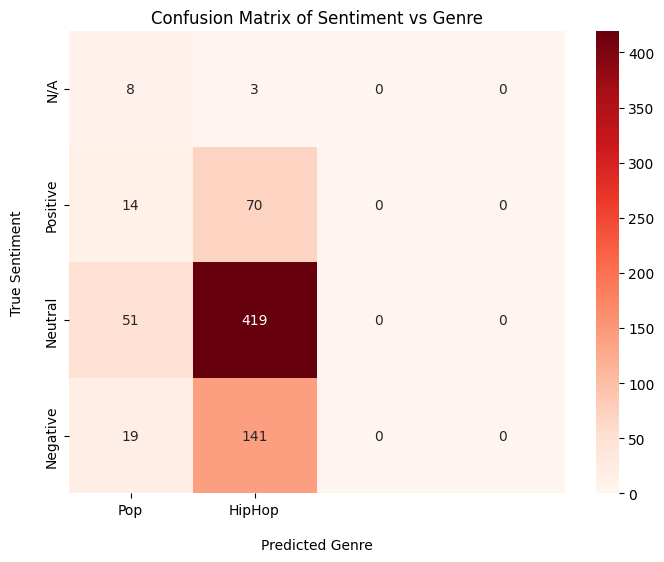

In [54]:
#visualising the confusion matrix
sentiment_mapping = {0: 'N/A', 1: 'Positive', 2: 'Neutral', 3: 'Negative'}

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Pop', 'HipHop'], 
            yticklabels=[sentiment_mapping[i] for i in range(len(sentiment_mapping))])
plt.ylabel('True Sentiment', labelpad=15)
plt.xlabel('Predicted Genre', labelpad=15)
plt.title('Confusion Matrix of Sentiment vs Genre')
plt.show()

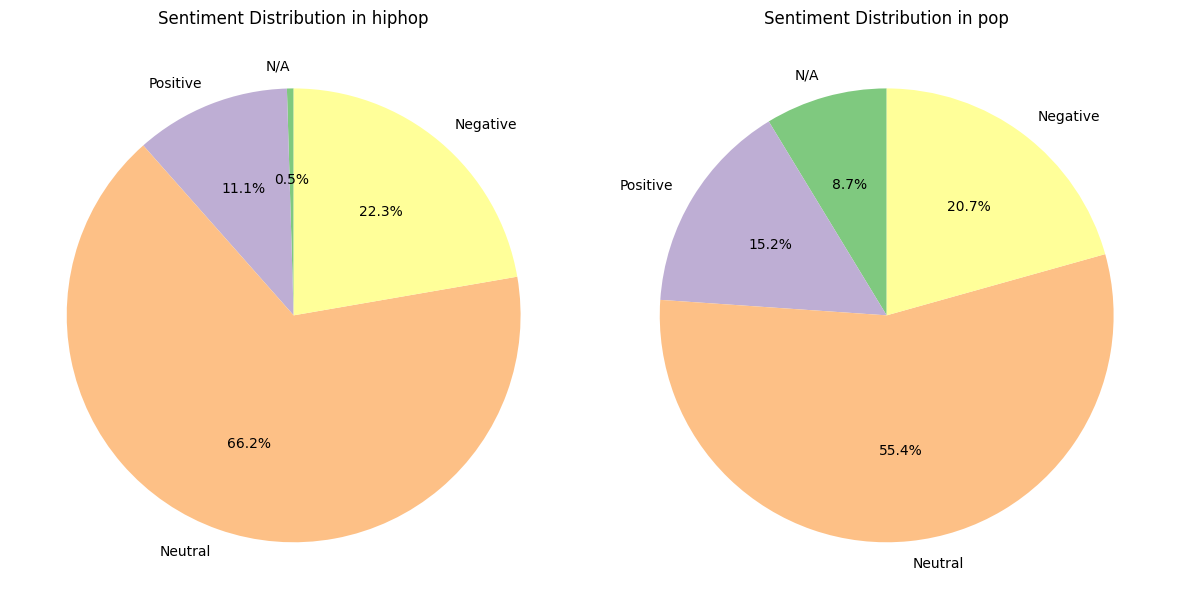

In [68]:
#Visualising each genre as pie charts
sentiment_counts = s_df.groupby(['Genre', 'Sentiment Annotation (Natalie)']).size().unstack(fill_value=0)
sentiment_percentage = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

# Reset the index for easier plotting
sentiment_percentage = sentiment_percentage.reset_index()

sentiment_mapping = {0: 'N/A', 1: 'Positive', 2: 'Neutral', 3: 'Negative'}
sentiment_percentage.columns = ['Genre'] + [sentiment_mapping[i] for i in range(len(sentiment_mapping))]

genres = sentiment_percentage['Genre'].unique()

# Set up the figure for pie charts
fig, axes = plt.subplots(1, len(genres), figsize=(12, 6))

for ax, genre in zip(axes, genres):
    # Get the sentiment data for the current genre
    sentiment_data = sentiment_percentage[sentiment_percentage['Genre'] == genre].iloc[:, 1:]
    
    # Create a pie chart
    ax.pie(sentiment_data.values.flatten(), 
            labels=sentiment_data.columns, 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=sns.color_palette('Accent', n_colors=len(sentiment_data.columns)))
    
    ax.set_title(f'Sentiment Distribution in {genre}')

plt.tight_layout()
plt.show()

These visualisations reveals that despite the frequency of curse words, they contradict the assumption that the genre is inherently aggressive or misogynistic, at least within this select corpus. Since the _sentiment_ was analysed, the same swear word, 'bitch', 'damn', etc., can mean and imply different things based on context. 
<br> 
<br>
In fact, other than those lyrics annotated as 'N/A' for various reasons, the sentiment distribution is not so starkly different as the _amount_ of profanity. In fact, both genres' negative usage of profanity was quite similar with 22.3% and 20.7% in hip hop and pop respectively. While pop lyrics appear to make use of profanity for positive reasons more often with 15.2% versus hip hop's 11.1%. 
<br> 
<br>
The majority of the profanity in both genres in our corpus appear to be of neutral sentiment i.e. is neither used in a negative or positive way, or most likely used as an intensifier (as noted in the annotation guidelines). More than half the swear words in both genres were neutral, with a surprising 66.2% of the profanity in hip hop being neutral. 

### Conclusions & Limitations
In conclusion, our research reveals that while hip hop/rap artists definitely uses profanity significantly more frequently than pop artists, their usage is not as straight forward as assumed by most people nor is it inherently "aggressive, offensive, misogynistic or even violent" as stated in the introduction of this project (Howard et al., 2021). Though it should be noted that this applies to our corpus, specifically, the songs for which were chosen from Shazam's Top 100 Radio Charts of 2024 i.e. songs most often played on the radio in 2024. Though the profanity was most likely censored for radio play, it does mean that songs which may in fact have presented more negative sentiment in their profanity were not even considered for radio. <br> 
<br> 
Other Limitations: <ul>
    <li>Includes music released in earlier years</li>
    <li>The irregular formatting of AZLyrics urls led to the exclusion of some songs from the corpus (6 hip-hop songs, 10 pop songs).</li>
    <li>Certain words, though not profanity, were identified as such. Sometimes as a result of pre-processing.</li>
    <li>The comparison was only between hip-hop and pop, so it cannot confirm that rap as a genre is the most profanity laden genre.</li>
    <li>The weakening of barriers between genres and the popularity of rap has led to the presence of rap in pop music (and in other genres) which might have skewed the results and possibly songs being placed in the 'wrong' genre.</li>
    <li> This corpus is limited to the music popular on the radio in 2024 and therefore cannot aid in making a blanket statement about the use of profanity within hip hop and pop in general - only the music popular in this specific year </li>
</ul>
<br>

**Future research:** <br>
This project could be used as a jumping off point for many other avenues of research in the usage of profanity in music. For one, it could be repeated for multiple years/eras to track trends in profanity usage in popular music - the frequency, choice of swear words, and the sentiment. It could also be used to compare genres like rap and metal - both of which are viewed as aggressive and violent - to examine the differences or similarities, much like it was done here. It could also be used to examine the use of profanity in different languages, or even if there is a difference between artists from different English speaking countries to present a point of social and/or cultural differences.

## Active Learning Exercises

- In original notebook

## References

Bruner, R. (2018). How hip-hop became the sound of the mainstream. Time. 
https://time.com/5118041/rap-music-mainstream/

Dictionary.com. (2025). Rap (music). https://www.dictionary.com/browse/rap--music 

Howard, S., Hennes, E. P., & Sommers, S. R. (2021). Stereotype Threat Among Black Men Following Exposure to Rap Music. Social Psychological and Personality Science, 12(5), 719-730. https://doi.org/10.1177/1948550620936852 

Medium. (2015). Profanity in lyrics: Most used swear words and their usage by popular genres. Medium. https://medium.com/musixmatch-blog/profanity-in-lyrics-most-used-swear-words-and-their-usage-by-popular-genres-d8a12c776713

Medium. (2022). What is hip-hop and how is it different from rap? Medium. https://medium.com/@byvinci.io/what-is-hip-hop-and-how-is-it-different-from-rap-5726264814c9

Moloney, M. J., & Sylva, H. M. (2020). 'And I Swear...' – Profanity in pop music lyrics on the American Billboard charts 2009-2018 and the effect on YouTube popularity. International Journal of Scientific & Technology Research, 9(2), 5212-5214. 

Musical Dictionary. (2024). What is pop: Understanding pop music and its cultural significance. https://www.musicaldictionary.com/what-is-pop/ 